In [1]:
import os 
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Coupled Raman Hybrid Model

In [2]:
scenario_list = ["Scenario 1", "Scenario 2", "Scenario 3"]

In [3]:
full_coupled_dict = {}

for j in range(len(scenario_list)):
    
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[j] + "/(322)_ANN"
    coupled_list = os.listdir(couple_dir)

    couple_file_dict = {}

    couple_file_dict["0.2"] = []
    couple_file_dict["0.6"] = []

    for i in range(len(coupled_list)):
        if ".pkl" in coupled_list[i]:
            spcovp = coupled_list[i].split("_")[4]
            couple_file_dict[spcovp].append(coupled_list[i])
    
    full_coupled_dict[scenario_list[j]] = couple_file_dict

In [4]:
splist = ["0.2", "0.6"]
full_coupled_compute_time = {}
for z in range(2):
    spcovp = splist[z]
    coupled_ct = {}
    for k in range(len(scenario_list)):
        couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
        couple_file_dict = full_coupled_dict[scenario_list[k]]

        C6_performance_list = couple_file_dict[spcovp]

        C6_unique_dict = {}
        for i in range(len(C6_performance_list)):
            name = C6_performance_list[i]
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = tuple([k1, k2])

            if ky not in list(C6_unique_dict.keys()):
                C6_unique_dict[ky] = []

            filepath = os.path.join(couple_dir, name)
            with open(filepath, "rb") as f:
                data = pickle.load(f)["Compute Time"]

            C6_unique_dict[ky].append(data)

        coupled_ct[scenario_list[k]] = C6_unique_dict
    
    full_coupled_compute_time[spcovp] = coupled_ct

In [5]:
crhm_mean_time = np.zeros((2, 3, 3))
crhm_std_time = np.zeros((2, 3, 3))
full =[]

for z in range(len(splist)):
    coupled_ct = full_coupled_compute_time[splist[z]]
    for k in range(len(scenario_list)):
        C6_compute = coupled_ct[scenario_list[k]]
        keys = list(C6_compute)
        for i in range(len(keys)):
            data = np.array(C6_compute[keys[i]])/60
            crhm_mean_time[z, k, i] = np.mean(data)
            crhm_std_time[z, k, i] = np.std(data)
            full.append(data)
full = np.array(full)
print("CRHM Wall Clock Time (min)")
print("Minimum wall clock time:", round(np.min(full), 2))
print("Maximum wall clock time:", round(np.max(full), 2))
print("Mean wall clock time:", round(np.mean(full), 2))
print("Median wall clock time:", round(np.median(full), 2))

CRHM Wall Clock Time (min)
Minimum wall clock time: 2.64
Maximum wall clock time: 22.52
Mean wall clock time: 14.04
Median wall clock time: 16.43


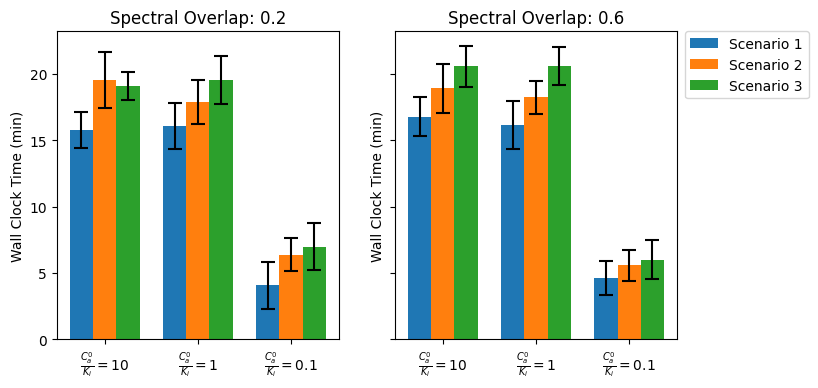

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
ax = axs.ravel()

for z in range(len(splist)):
    data_m = crhm_mean_time[z, :, :]
    data_s = crhm_std_time[z, :, :]

    n_rows, n_cols = data_m.shape
    x = np.arange(n_rows)
    width = 0.25

    colors = ['tab:blue', 'tab:orange', 'tab:green']
    labels = scenario_list

    for j in range(n_cols):
        ax[z].bar(
            x + (j - (n_cols - 1)/2) * width,
            data_m[:, j],
            width,
            color=colors[j],
            label=labels[j],
            yerr=data_s[:, j],
            capsize=5,
            ecolor='black',
            error_kw={
                'elinewidth': 1.5,
                'capthick': 1.5
            }
        )

    ax[z].set_title("Spectral Overlap: " + splist[z])
    ax[z].set_xticks(x)
    ax[z].set_xticklabels([
        r"$\frac{C_a^0}{K_i} = 10$",
        r"$\frac{C_a^0}{K_i} = 1$",
        r"$\frac{C_a^0}{K_i} = 0.1$"
    ])
    ax[z].set_ylabel('Wall Clock Time (min)')

# Get legend entries from first subplot
handles, labels = ax[0].get_legend_handles_labels()

pos = ax[1].get_position()  # position of right subplot

fig.legend(
    handles,
    labels,
    loc='upper left',
    bbox_to_anchor=(pos.x1 + 0.01, pos.y1),
    bbox_transform=fig.transFigure,
    borderaxespad=0.0
)
plt.show()

# Iterative Raman Hybrid Model - SVD initialization

In [7]:
full_iterative_dict = {}

for j in range(len(scenario_list)):
    
    iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[j] + "/(322)_ANN"
    iterative_list = os.listdir(iterative_dir)

    iterative_file_dict = {}

    iterative_file_dict["0.2"] = []
    iterative_file_dict["0.6"] = []

    for i in range(len(iterative_list)):
        if ".pkl" in iterative_list[i]:
            spcovp = iterative_list[i].split("_")[4]
            iterative_file_dict[spcovp].append(iterative_list[i])
    
    full_iterative_dict[scenario_list[j]] = iterative_file_dict

In [8]:
splist = ["0.2", "0.6"]
full_iterative_svd_compute_time = {}

for z in range(2):
    spcovp = splist[z]
    coupled_ct = {}

    for k in range(len(scenario_list)):
        iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[k] + "/(322)_ANN"
        iterative_file_dict = full_iterative_dict[scenario_list[k]]

        I6_performance_list = iterative_file_dict[spcovp]

        I6_unique_dict = {}
        for i in range(len(I6_performance_list)):
            name = I6_performance_list[i]
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = tuple([k1, k2])

            if ky not in list(I6_unique_dict.keys()):
                I6_unique_dict[ky] = []

            filepath = os.path.join(iterative_dir, name)
            with open(filepath, "rb") as f:
                data = pickle.load(f)["Compute Time"]

            I6_unique_dict[ky].append(data)

        coupled_ct[scenario_list[k]] = I6_unique_dict
    
    full_iterative_svd_compute_time[spcovp] = coupled_ct

In [9]:
irhm_svd_mean_time = np.zeros((2, 3, 3))
irhm_svd_std_time = np.zeros((2, 3, 3))
full = []

for z in range(len(splist)):
    coupled_ct = full_iterative_svd_compute_time[splist[z]]
    for k in range(len(scenario_list)):
        C6_compute = coupled_ct[scenario_list[k]]
        keys = list(C6_compute)
        for i in range(len(keys)):
            data = np.array(C6_compute[keys[i]])/60
            irhm_svd_mean_time[z, k, i] = np.mean(data)
            irhm_svd_std_time[z, k, i] = np.std(data)
            full.append(data)
full = np.array(full)
print("IRHM-SVD Wall Clock Time (min)")
print("Minimum wall clock time:", round(np.min(full), 2))
print("Maximum wall clock time:", round(np.max(full), 2))
print("Mean wall clock time:", round(np.mean(full), 2))
print("Median wall clock time:", round(np.median(full), 2))

IRHM-SVD Wall Clock Time (min)
Minimum wall clock time: 2.92
Maximum wall clock time: 71.79
Mean wall clock time: 22.56
Median wall clock time: 25.01


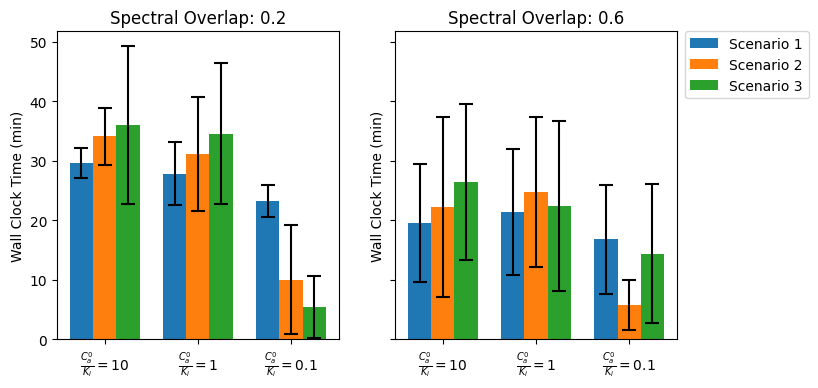

In [10]:
fig, axs = plt.subplots(1, 2, figsize = (8, 4), sharex = True, sharey = True)
ax = axs.ravel()

for z in range(len(splist)):
    data_m = irhm_svd_mean_time[z, :, :]
    data_s = irhm_svd_std_time[z, :, :]
    
    n_rows, n_cols = data_m.shape
    x = np.arange(n_rows)
    width = 0.25

    colors = ['tab:blue', 'tab:orange', 'tab:green']
    labels = scenario_list

    for j in range(n_cols):
        ax[z].bar(
            x + (j - (n_cols - 1)/2) * width,
            data_m[:, j],
            width,
            color=colors[j],
            label=labels[j],
            yerr=data_s[:, j],      # Standard deviations
            capsize=5,          # Length of error bar caps
            ecolor='black',     # Error bar color
            error_kw={
                'elinewidth': 1.5,
                'capthick': 1.5
            }
        )

    ax[z].set_title("Spectral Overlap: " + splist[z])
    ax[z].set_xticks(x)
    ax[z].set_xticklabels([
        r"$\frac{C_a^0}{K_i} = 10$",
        r"$\frac{C_a^0}{K_i} = 1$",
        r"$\frac{C_a^0}{K_i} = 0.1$"
    ])
    ax[z].set_ylabel('Wall Clock Time (min)')

# Get legend entries from first subplot
handles, labels = ax[0].get_legend_handles_labels()

pos = ax[1].get_position()  # position of right subplot

fig.legend(
    handles,
    labels,
    loc='upper left',
    bbox_to_anchor=(pos.x1 + 0.01, pos.y1),
    bbox_transform=fig.transFigure,
    borderaxespad=0.0
)
plt.show()

# Iterative Raman Hybrid Model - SIMPLISMA

In [11]:
full_iterative_dict = {}

for j in range(len(scenario_list)):
    
    iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[j] + "/(322)_ANN"
    iterative_list = os.listdir(iterative_dir)

    iterative_file_dict = {}

    iterative_file_dict["0.2"] = []
    iterative_file_dict["0.6"] = []

    for i in range(len(iterative_list)):
        if ".pkl" in iterative_list[i]:
            spcovp = iterative_list[i].split("_")[4]
            iterative_file_dict[spcovp].append(iterative_list[i])
    
    full_iterative_dict[scenario_list[j]] = iterative_file_dict

In [12]:
splist = ["0.2", "0.6"]
full_iterative_sml_compute_time = {}

for z in range(2):
    spcovp = splist[z]
    coupled_ct = {}

    for k in range(len(scenario_list)):
        iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[k] + "/(322)_ANN"
        iterative_file_dict = full_iterative_dict[scenario_list[k]]

        I6_performance_list = iterative_file_dict[spcovp]

        I6_unique_dict = {}
        for i in range(len(I6_performance_list)):
            name = I6_performance_list[i]
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = tuple([k1, k2])

            if ky not in list(I6_unique_dict.keys()):
                I6_unique_dict[ky] = []

            filepath = os.path.join(iterative_dir, name)
            with open(filepath, "rb") as f:
                data = pickle.load(f)["Compute Time"]

            I6_unique_dict[ky].append(data)

        coupled_ct[scenario_list[k]] = I6_unique_dict
    
    full_iterative_sml_compute_time[spcovp] = coupled_ct

In [13]:
irhm_sml_mean_time = np.zeros((2, 3, 3))
irhm_sml_std_time = np.zeros((2, 3, 3))
full = []

for z in range(len(splist)):
    coupled_ct = full_iterative_sml_compute_time[splist[z]]
    for k in range(len(scenario_list)):
        C6_compute = coupled_ct[scenario_list[k]]
        keys = list(C6_compute)
        for i in range(len(keys)):
            data = np.array(C6_compute[keys[i]])/60
            irhm_sml_mean_time[z, k, i] = np.mean(data)
            irhm_sml_std_time[z, k, i] = np.std(data)
            full.append(data)
full = np.array(full)
print("IRHM-SIMPLISMA Wall Clock Time (min)")
print("Minimum wall clock time:", round(np.min(full), 2))
print("Maximum wall clock time:", round(np.max(full), 2))
print("Mean wall clock time:", round(np.mean(full), 2))
print("Median wall clock time:", round(np.median(full), 2))

IRHM-SIMPLISMA Wall Clock Time (min)
Minimum wall clock time: 2.92
Maximum wall clock time: 87.45
Mean wall clock time: 29.7
Median wall clock time: 29.4


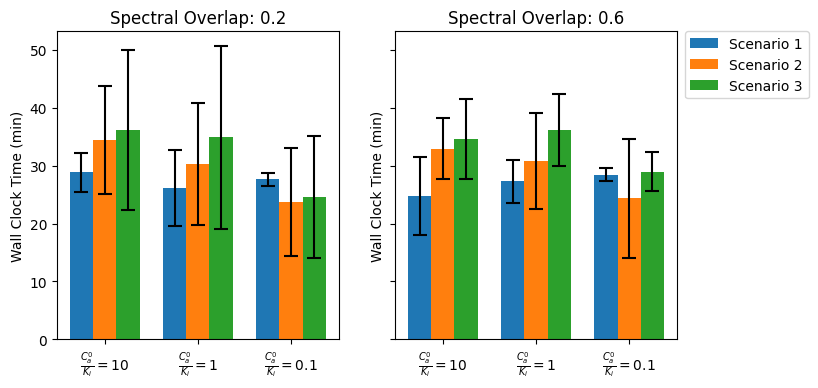

In [14]:
fig, axs = plt.subplots(1, 2, figsize = (8, 4), sharex = True, sharey = True)
ax = axs.ravel()

for z in range(len(splist)):
    data_m = irhm_sml_mean_time[z, :, :]
    data_s = irhm_sml_std_time[z, :, :]
    
    n_rows, n_cols = data_m.shape
    x = np.arange(n_rows)
    width = 0.25

    colors = ['tab:blue', 'tab:orange', 'tab:green']
    labels = scenario_list

    for j in range(n_cols):
        ax[z].bar(
            x + (j - (n_cols - 1)/2) * width,
            data_m[:, j],
            width,
            color=colors[j],
            label=labels[j],
            yerr=data_s[:, j],      # Standard deviations
            capsize=5,          # Length of error bar caps
            ecolor='black',     # Error bar color
            error_kw={
                'elinewidth': 1.5,
                'capthick': 1.5
            }
        )

    ax[z].set_title("Spectral Overlap: " + splist[z])
    ax[z].set_xticks(x)
    ax[z].set_xticklabels([
        r"$\frac{C_a^0}{K_i} = 10$",
        r"$\frac{C_a^0}{K_i} = 1$",
        r"$\frac{C_a^0}{K_i} = 0.1$"
    ])
    ax[z].set_ylabel('Wall Clock Time (min)')

# Get legend entries from first subplot
handles, labels = ax[0].get_legend_handles_labels()

pos = ax[1].get_position()  # position of right subplot

fig.legend(
    handles,
    labels,
    loc='upper left',
    bbox_to_anchor=(pos.x1 + 0.01, pos.y1),
    bbox_transform=fig.transFigure,
    borderaxespad=0.0
)
plt.show()

# Coupled Raman Mechanistic Model

In [16]:
full_coupled_phenom_dict = {}

for j in range(len(scenario_list)):
    
    couple_dir = "Coupled Performance/Mechanistic model/" + scenario_list[j]
    coupled_list = os.listdir(couple_dir)

    couple_file_dict = {}

    couple_file_dict["0.2"] = []
    couple_file_dict["0.6"] = []

    for i in range(len(coupled_list)):
        if ".pkl" in coupled_list[i]:
            spcovp = coupled_list[i].split("_")[4]
            couple_file_dict[spcovp].append(coupled_list[i])
    
    full_coupled_phenom_dict[scenario_list[j]] = couple_file_dict

In [17]:
splist = ["0.2", "0.6"]
full_coupled_phenom_compute_time = {}

for z in range(2):
    spcovp = splist[z]
    coupled_ct = {}

    for k in range(len(scenario_list)):
        couple_dir = "Coupled Performance/Mechanistic model/" + scenario_list[k]
        couple_file_dict = full_coupled_phenom_dict[scenario_list[k]]

        C6_performance_list = couple_file_dict[spcovp]

        C6_unique_dict = {}
        for i in range(len(C6_performance_list)):
            name = C6_performance_list[i]
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = tuple([k1, k2])

            if ky not in list(C6_unique_dict.keys()):
                C6_unique_dict[ky] = []

            filepath = os.path.join(couple_dir, name)
            with open(filepath, "rb") as f:
                data = pickle.load(f)["Compute Time"]
            C6_unique_dict[ky].append(data)

        coupled_ct[scenario_list[k]] = C6_unique_dict
    
    full_coupled_phenom_compute_time[spcovp] = coupled_ct

In [18]:
crmm_mean_time = np.zeros((2, 3, 3))
crmm_std_time = np.zeros((2, 3, 3))
full = []
for z in range(len(splist)):
    coupled_ct = full_coupled_phenom_compute_time[splist[z]]
    for k in range(len(scenario_list)):
        C6_compute = coupled_ct[scenario_list[k]]
        keys = list(C6_compute)
        for i in range(len(keys)):
            data = np.array(C6_compute[keys[i]])/60
            crmm_mean_time[z, k, i] = np.mean(data)
            crmm_std_time[z, k, i] = np.std(data)
            full.append(data)
full = np.array(full)
print("IRHM-SIMPLISMA Wall Clock Time (min)")
print("Minimum wall clock time:", round(np.min(full), 2))
print("Maximum wall clock time:", round(np.max(full), 2))
print("Mean wall clock time:", round(np.mean(full), 2))
print("Median wall clock time:", round(np.median(full), 2))

IRHM-SIMPLISMA Wall Clock Time (min)
Minimum wall clock time: 1.44
Maximum wall clock time: 6.32
Mean wall clock time: 2.43
Median wall clock time: 2.5


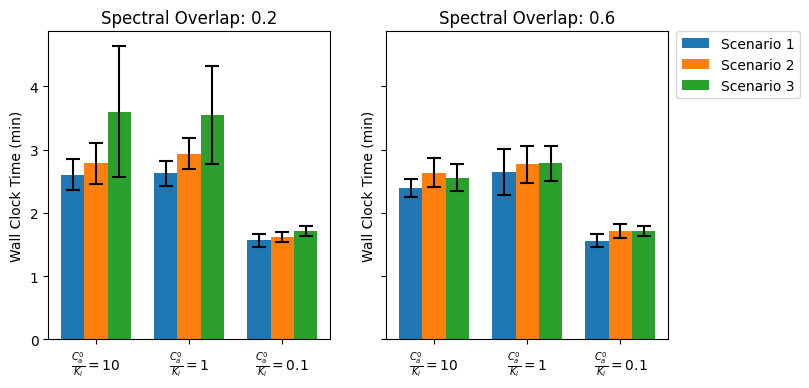

In [19]:
fig, axs = plt.subplots(1, 2, figsize = (8, 4), sharex = True, sharey = True)
ax = axs.ravel()

for z in range(len(splist)):
    data_m = crmm_mean_time[z, :, :]
    data_s = crmm_std_time[z, :, :]
    
    n_rows, n_cols = data_m.shape
    x = np.arange(n_rows)
    width = 0.25

    colors = ['tab:blue', 'tab:orange', 'tab:green']
    labels = scenario_list

    for j in range(n_cols):
        ax[z].bar(
            x + (j - (n_cols - 1)/2) * width,
            data_m[:, j],
            width,
            color=colors[j],
            label=labels[j],
            yerr=data_s[:, j],      # Standard deviations
            capsize=5,          # Length of error bar caps
            ecolor='black',     # Error bar color
            error_kw={
                'elinewidth': 1.5,
                'capthick': 1.5
            }
        )

    ax[z].set_title("Spectral Overlap: " + splist[z])
    ax[z].set_xticks(x)
    ax[z].set_xticklabels([
        r"$\frac{C_a^0}{K_i} = 10$",
        r"$\frac{C_a^0}{K_i} = 1$",
        r"$\frac{C_a^0}{K_i} = 0.1$"
    ])
    ax[z].set_ylabel('Wall Clock Time (min)')

# Get legend entries from first subplot
handles, labels = ax[0].get_legend_handles_labels()

pos = ax[1].get_position()  # position of right subplot

fig.legend(
    handles,
    labels,
    loc='upper left',
    bbox_to_anchor=(pos.x1 + 0.01, pos.y1),
    bbox_transform=fig.transFigure,
    borderaxespad=0.0
)
plt.show()